<a href="https://colab.research.google.com/github/mmaksim1234/store/blob/main/123.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mamba install pandas numpy matplotlib scikit-learn

/bin/bash: line 1: mamba: command not found


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Найкраще значення К для класифікації: 3 з точністю 1.0000


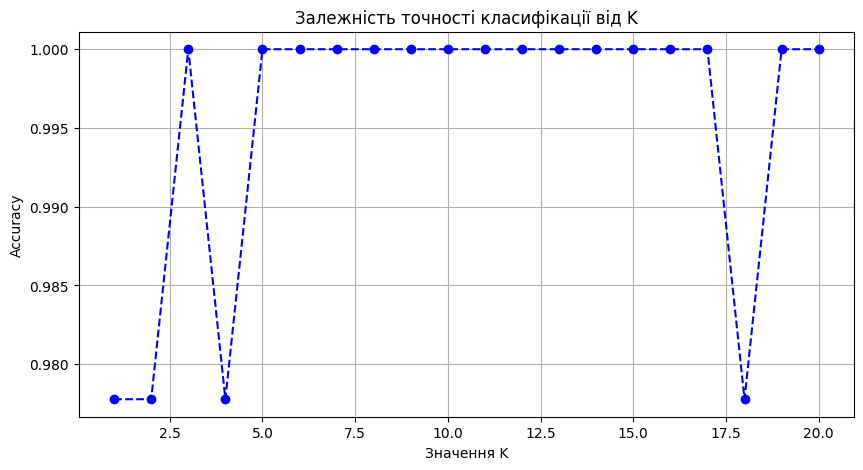

In [3]:
ks = range(1, 21)
accuracies = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = ks[np.argmax(accuracies)]
print(f"Найкраще значення К для класифікації: {best_k} з точністю {max(accuracies):.4f}")

# Візуалізація результатів класифікації
plt.figure(figsize=(10, 5))
plt.plot(ks, accuracies, marker='o', linestyle='--', color='b')
plt.title('Залежність точності класифікації від K')
plt.xlabel('Значення K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [4]:
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(1000, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0]) # Додаємо шум

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

mse_values = []
ks_reg = range(1, 31)

for k in ks_reg:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_r, y_train_r)
    y_pred_r = knn_reg.predict(X_test_r)
    mse_values.append(mean_squared_error(y_test_r, y_pred_r))

best_k_reg = ks_reg[np.argmin(mse_values)]
print(f"Найкраще значення К для регресії: {best_k_reg}")

Найкраще значення К для регресії: 19


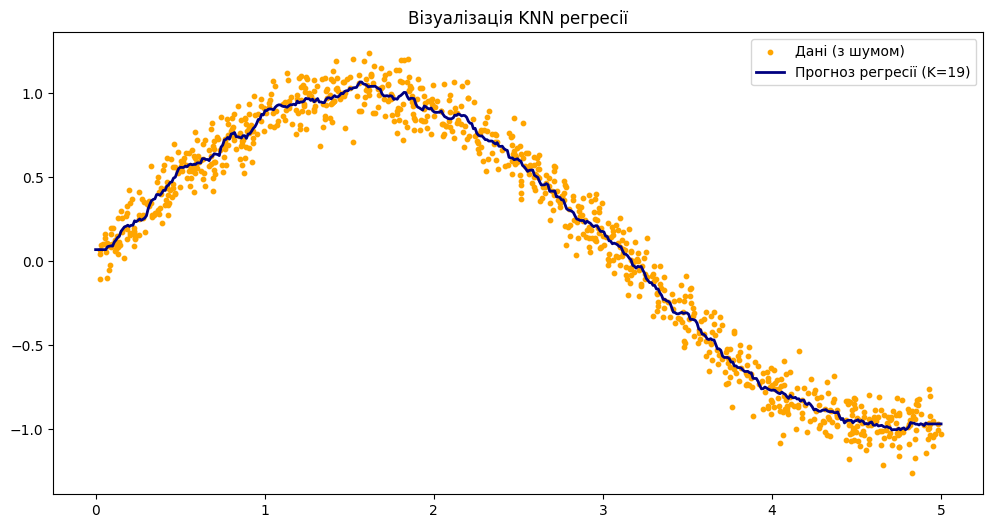

In [5]:
# 5. Здійснити візуалізації отриманих рішень
T = np.linspace(0, 5, 500)[:, np.newaxis]
knn_final = KNeighborsRegressor(n_neighbors=best_k_reg)
knn_final.fit(X_train_r, y_train_r)
y_final = knn_final.predict(T)

plt.figure(figsize=(12, 6))
plt.scatter(X_reg, y_reg, color='orange', label='Дані (з шумом)', s=10)
plt.plot(T, y_final, color='navy', label=f'Прогноз регресії (K={best_k_reg})', linewidth=2)
plt.title('Візуалізація KNN регресії')
plt.legend()
plt.show()